<a href="https://colab.research.google.com/github/Dwara97/MIC_project/blob/main/MIC_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
df = pd.read_csv('drive/MyDrive/Colab Notebooks/MIC /flight_pricing_dataset.csv')

In [3]:
df['Total_Stops'] = df['Total_Stops'].replace({
    'non-stop': 0,
    '1 stop': 1,
    '2 stops': 2,
    '3 stops': 3
})
df['Total_Stops'] = pd.to_numeric(df['Total_Stops'])

In [4]:
def duration_in_dec(val):
  val=str(val)
  if 'h'in val:
    hours=0
    minutes=0
    hours=int(val.split('h')[0].strip())
    minutes=int(val.split('h')[1].replace('m','').strip())
    return round(hours+minutes/60,2)
  elif 'm' in val:
    minutes=0
    minutes=int(val.split('m')[0].strip())
    return round(minutes/60,2)
  else:
    return float(val)
df['Duration_hrs']=df['Duration'].apply(duration_in_dec)



In [5]:
df['Price']=df['Price'].astype(str)
df['Price']=df['Price'].str.replace('Rs.','',regex=False)
df['Price']=df['Price'].str.replace(',','',regex=False)
df['Price']=pd.to_numeric(df['Price'],errors='coerce')
df['Distance_km']=df['Distance_km'].astype(str)
df['Distance_km']=df['Distance_km'].str.replace('km','',regex=False)
df['Distance_km']=df['Distance_km'].str.strip()
df['Distance_km']=pd.to_numeric(df['Distance_km'],errors='coerce')
df['Days_Before_Departure']=df['Days_Before_Departure'].astype(str)
df['Days_Before_Departure']=df['Days_Before_Departure'].str.replace('days','',regex=False)
df['Days_Before_Departure']=df['Days_Before_Departure'].str.strip()
df['Days_Before_Departure']=pd.to_numeric(df['Days_Before_Departure'],errors='coerce')
df['Passenger_Count']=df['Passenger_Count'].astype(str)
df['Passenger_Count']=df['Passenger_Count'].str.replace('two','2',regex=False)
df['Passenger_Count']=df['Passenger_Count'].str.replace('four','4',regex=False)
df['Passenger_Count']=df['Passenger_Count'].str.replace('one','1',regex=False)
df['Passenger_Count']=df['Passenger_Count'].str.replace('three','3',regex=False)
df['Passenger_Count']=df['Passenger_Count'].str.replace('six','6',regex=False)
df['Passenger_Count']=df['Passenger_Count'].str.replace('five','5',regex=False)
df['Passenger_Count']=pd.to_numeric(df['Passenger_Count'],errors='coerce')




In [6]:
df_clean = df.dropna(subset=['Price', 'Duration_hrs', 'Total_Stops', 'Distance_km',
                               'Days_Before_Departure', 'Airline', 'Source', 'Destination',
                               'Travel_Class', 'Season', 'Passenger_Count'])
print(df_clean.shape)

(57615, 19)


In [7]:
print("Original rows:", df.shape[0])
print("Cleaned rows:", df_clean.shape[0])
print()
print(df_clean.isnull().sum())
print()
print(df_clean.describe())

Original rows: 100000
Cleaned rows: 57615

Flight_ID                   0
Airline                     0
Source                      0
Destination                 0
Departure_Date           2841
Departure_Time           2792
Arrival_Time             2781
Duration                    0
Total_Stops                 0
Distance_km                 0
Travel_Class                0
Days_Before_Departure       0
Season                      0
Weekday                  2750
Aircraft_Type            2807
Booking_Channel          2850
Passenger_Count             0
Price                       0
Duration_hrs                0
dtype: int64

        Total_Stops   Distance_km  Days_Before_Departure  Passenger_Count  \
count  57615.000000  57615.000000           57615.000000     57615.000000   
mean       0.727571   5144.570957              35.849640         2.118355   
std        0.676690   4412.470478              43.686474         1.307723   
min        0.000000    150.000000               0.000000         

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

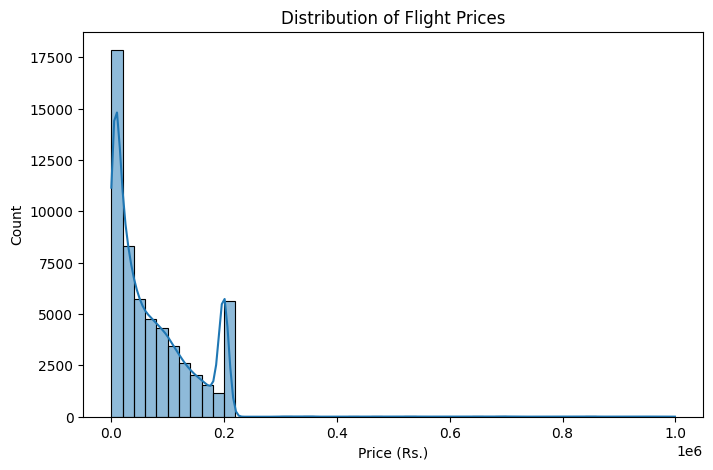

In [9]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Price'], bins=50, kde=True)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price (Rs.)')
plt.show()

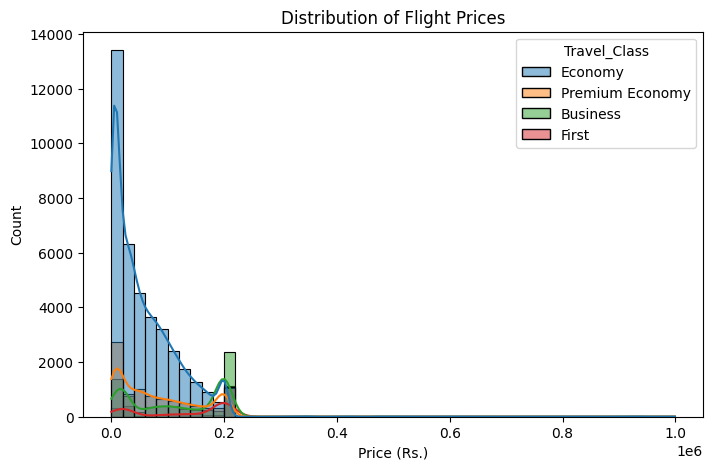

In [10]:
# this one gives extra info.
plt.figure(figsize=(8,5))
sns.histplot(data=df_clean, x='Price', hue='Travel_Class', bins=50, kde=True)
plt.title('Distribution of Flight Prices')
plt.xlabel('Price (Rs.)')
plt.show()

In [11]:
df_clean['Airline'] = df_clean['Airline'].str.strip().str.title()

/tmp/ipykernel_673/2555438068.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Airline'] = df_clean['Airline'].str.strip().str.title()


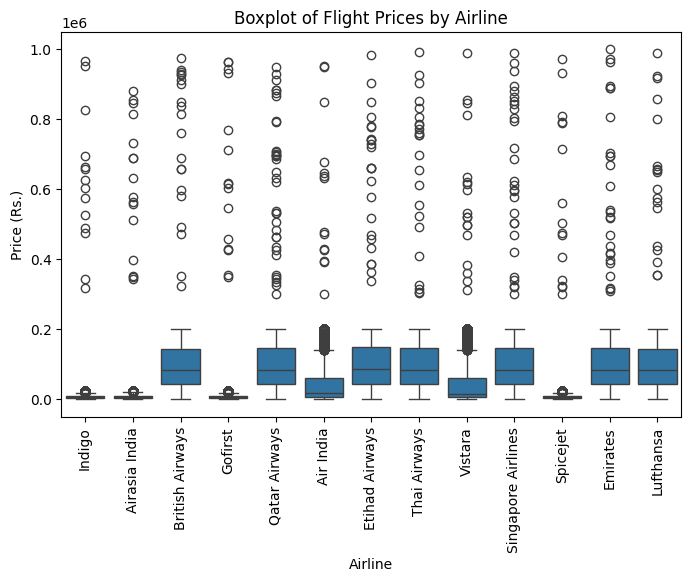

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='Airline',y='Price')
plt.xticks(rotation=90)
plt.title('Boxplot of Flight Prices by Airline')
plt.xlabel('Airline')
plt.ylabel('Price (Rs.)')
plt.show()

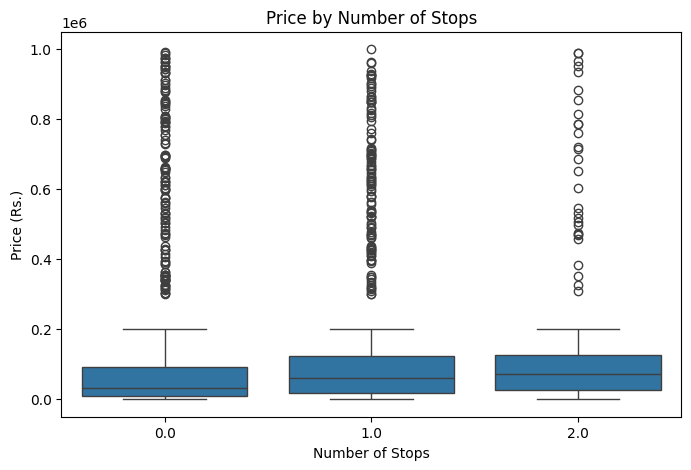

In [13]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_clean, x='Total_Stops',y='Price')
plt.title('Price by Number of Stops')
plt.xlabel('Number of Stops')
plt.ylabel('Price (Rs.)')
plt.show()

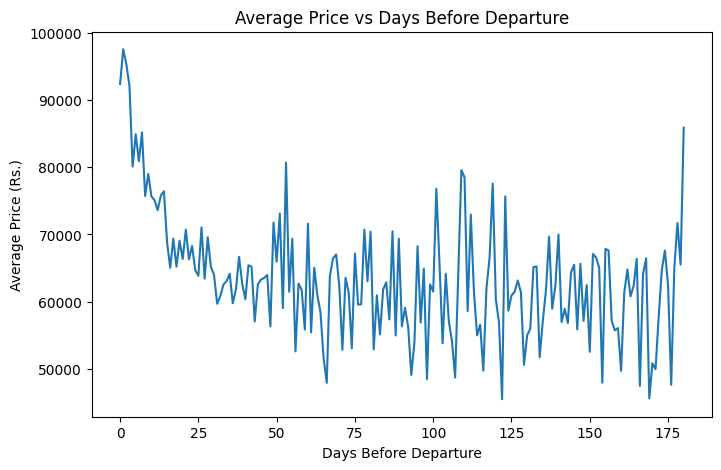

In [14]:
plt.figure(figsize=(8,5))
avg_price_by_days=df_clean.groupby('Days_Before_Departure')['Price'].mean().reset_index()
sns.lineplot(data=avg_price_by_days, x='Days_Before_Departure', y='Price')
plt.title('Average Price vs Days Before Departure')
plt.xlabel('Days Before Departure')
plt.ylabel('Average Price (Rs.)')
plt.show()

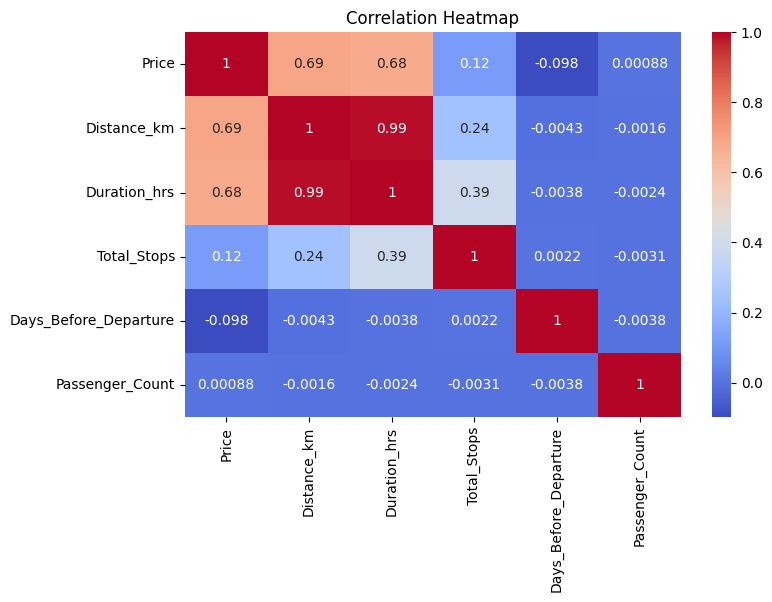

In [15]:
plt.figure(figsize=(8,5))
cols=['Price','Distance_km','Duration_hrs','Total_Stops','Days_Before_Departure','Passenger_Count']
sns.heatmap(df_clean[cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [16]:
#Now we are moving onto part 2
features=['Airline','Source','Destination','Travel_Class','Season','Distance_km','Duration_hrs','Total_Stops','Days_Before_Departure','Passenger_Count']
target=['Price']
df_model=df_clean[features+target].copy()
print(df_model.shape)
df_model.head()

(57615, 11)


,Airline,Source,Destination,Travel_Class,Season,Distance_km,Duration_hrs,Total_Stops,Days_Before_Departure,Passenger_Count,Price
0,Indigo,Hyderabad,Ahmedabad,Economy,Monsoon,910.5,1.67,0.0,43.0,5.0,5181.56
1,Airasia India,Pune,Mumbai,Economy,Monsoon,150.0,0.75,0.0,45.0,3.0,2000.00
3,Airasia India,Bangalore Airport,BOM,Economy,Summer,868.3,3.18,1.0,33.0,1.0,2846.09
4,British Airways,Sydney,Goa,Economy,Monsoon,10478.0,13.93,0.0,6.0,2.0,145331.64
6,Gofirst,Pune,Bangalore,Economy,Winter,748.9,1.47,0.0,3.0,2.0,6458.88


In [17]:
df_encoded=pd.get_dummies(df_model, columns=['Airline','Source','Destination','Travel_Class','Season'], drop_first=True)
print(df_encoded.shape)
df_encoded.head()

(57615, 130)


,Distance_km,Duration_hrs,Total_Stops,Days_Before_Departure,Passenger_Count,Price,Airline_Airasia India,Airline_British Airways,Airline_Emirates,Airline_Etihad Airways,...,Destination_Singapore,Destination_Singapore Airport,Destination_Sydney,Destination_Sydney Airport,Travel_Class_Economy,Travel_Class_First,Travel_Class_Premium Economy,Season_Monsoon,Season_Summer,Season_Winter
0,910.5,1.67,0.0,43.0,5.0,5181.56,False,False,False,False,...,False,False,False,False,True,False,False,True,False,False
1,150.0,0.75,0.0,45.0,3.0,2000.00,True,False,False,False,...,False,False,False,False,True,False,False,True,False,False
3,868.3,3.18,1.0,33.0,1.0,2846.09,True,False,False,False,...,False,False,False,False,True,False,False,False,True,False
4,10478.0,13.93,0.0,6.0,2.0,145331.64,False,True,False,False,...,False,False,False,False,True,False,False,True,False,False
6,748.9,1.47,0.0,3.0,2.0,6458.88,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True


In [18]:
from sklearn.model_selection import train_test_split
X=df_encoded.drop(columns=['Price'])
y=df_encoded['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape,X_test.shape)

(46092, 129) (11523, 129)


In [19]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [20]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
import numpy as np
y_pred=model.predict(X_test)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mean_squared_error(y_test,y_pred))
r2=r2_score(y_test,y_pred)
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")
print(f"R-squared: {r2:.2f}")

Mean Absolute Error: 13854.19
Root Mean Squared Error: 46375.40
R-squared: 0.62


In [21]:
importances=model.feature_importances_
feature_names=X_train.columns
importance_df=pd.DataFrame({'Feature': feature_names,'Importance': importances})
importance_df=importance_df.sort_values('Importance',ascending=False).head(15)

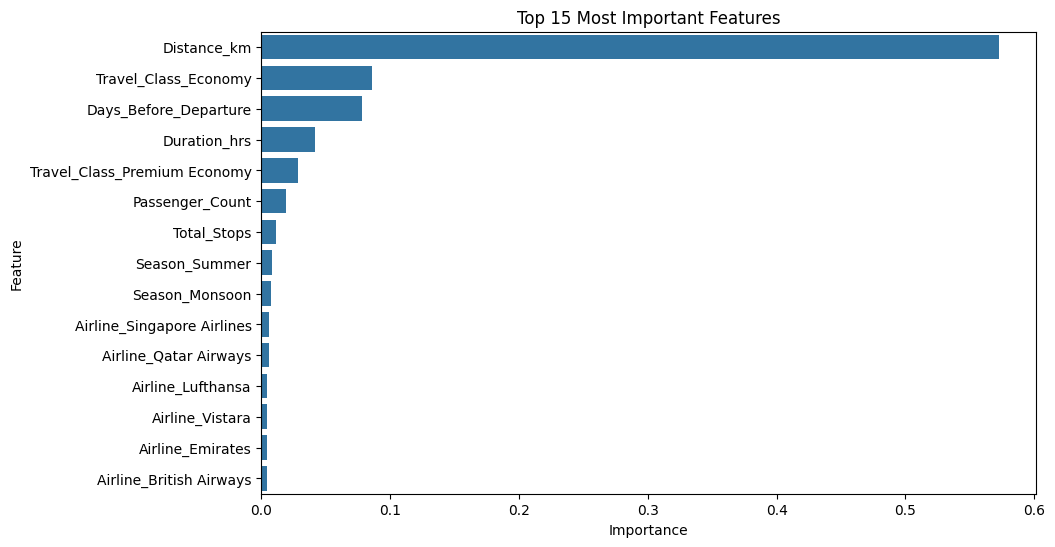

In [22]:
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df,x='Importance',y='Feature')
plt.title('Top 15 Most Important Features')
plt.show()